In [1]:
import pandas as pd
import glob
import numpy as np
import os
import re
from IPython.display import display

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# ── Fonts & style (Academic Paper Style) ──────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.labelsize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    9.5,
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "figure.dpi":         150,
    "savefig.dpi":        300,
})

# ── Config ────────────────────────────────────────────────────────────────────
FILTER_ZEROS = False
SEGMENTS = ["Contract", "General", "Perishable", "Express", "Spot"]

# Base Models
MODELS = ["Naive", "EM", "EMXPrice"]

# Dynamically add PD models based on tau
TAU_VALUES = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for tau in TAU_VALUES:
    tau_str = str(tau).replace('.', '')
    MODELS.extend([f"PD{tau_str}", f"PDXPrice{tau_str}"])

# Palette for Time Series plotting
COLORS = {
    "Oracle": "#1a1a2e",      # Deep navy/black
    "Observed": "#e63946",    # Crisp red
    "Estimate": "#4E79A7"     # Muted blue
}

In [2]:
def trim_burn_in(df_group):
    # Check for NaNs in any estimation columns
    est_cols = [f"{m}_{s}_Est" for m in MODELS for s in SEGMENTS if f"{m}_{s}_Est" in df_group.columns]
    valid_mask = df_group[est_cols].notna().all(axis=1)
    
    if not valid_mask.any():
        return pd.DataFrame()
        
    first_valid_idx = valid_mask.idxmax() 
    return df_group.loc[first_valid_idx:].copy()

files = glob.glob("./unconstrained_results/*.parquet")
print(f"Found {len(files)} files...")

df_all = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print("Trimming burn-in period...")
df_trimmed = df_all.groupby(['Origin', 'Destination'], as_index=False, group_keys=False).apply(trim_burn_in)

print("Calculating Totals...")
df_trimmed["Total_Oracle_kg"] = 0.0
df_trimmed["Total_Observed_kg"] = 0.0

for m in MODELS:
    df_trimmed[f"{m}_Total_Est"] = 0.0

for s in SEGMENTS:
    obs_col = f"Observed_{s}_kg"
    oracle_col = f"Oracle_{s}_kg"
    
    df_trimmed["Total_Oracle_kg"] += df_trimmed[oracle_col].fillna(0)
    df_trimmed["Total_Observed_kg"] += df_trimmed[obs_col].fillna(0)
    
    for m in MODELS:
        est_col = f"{m}_{s}_Est"
        df_trimmed[est_col] = df_trimmed[est_col].fillna(df_trimmed[obs_col]) # Safety fallback
        df_trimmed[f"{m}_Total_Est"] += df_trimmed[est_col]

df_analysis = df_trimmed.reset_index(drop=True)
print(f"Final Analysis Data Shape: {df_analysis.shape}")

Found 90 files...
Trimming burn-in period...


/tmp/ipykernel_2347194/2917999266.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_trimmed = df_all.groupby(['Origin', 'Destination'], as_index=False, group_keys=False).apply(trim_burn_in)


Calculating Totals...
Final Analysis Data Shape: (296010, 237)


In [3]:
route_results = []
EVAL_SEGMENTS = SEGMENTS + ["Total"]

for (o, d), g in df_analysis.groupby(["Origin", "Destination"]):
    for seg in EVAL_SEGMENTS:
        true_col = f"Oracle_{seg}_kg" if seg != "Total" else "Total_Oracle_kg"
        yt = g[true_col].values
        avg_demand = np.mean(yt[~np.isnan(yt)]) if len(yt[~np.isnan(yt)]) > 0 else 0
        
        for model in MODELS:
            est_col = f"{model}_{seg}_Est" if seg != "Total" else f"{model}_Total_Est"
            yp = g[est_col].values
            
            mask = ~np.isnan(yt) & ~np.isnan(yp)
            if mask.sum() < 2: continue
            
            yt_v, yp_v = yt[mask], yp[mask]
            
            mae = np.mean(np.abs(yt_v - yp_v))
            rmse = np.sqrt(mean_squared_error(yt_v, yp_v))
            wape = (np.sum(np.abs(yt_v - yp_v)) / np.sum(np.abs(yt_v))) * 100 if np.sum(np.abs(yt_v)) > 0 else np.nan
            r2 = r2_score(yt_v, yp_v)
            
            route_results.append({
                "Origin": o, "Destination": d, "Segment": seg, "Model": model,
                "Avg_Oracle_Demand": avg_demand,
                "MAE": mae, "RMSE": rmse, "WAPE": wape, "R2": r2
            })

df_route_metrics = pd.DataFrame(route_results)

# Global Summary
summary_df = df_route_metrics.groupby(["Model", "Segment"])[["MAE", "RMSE", "WAPE", "R2"]].mean().reset_index()

print("--- Global WAPE (%) by Segment ---")
display(summary_df.pivot(index="Model", columns="Segment", values="WAPE").round(2))

print("\n--- Global Aggregate Metrics (Total across all Products) ---")
global_total = summary_df[summary_df["Segment"] == "Total"].set_index("Model").drop(columns="Segment")
display(global_total.round(3))

--- Global WAPE (%) by Segment ---


Segment,Contract,Express,General,Perishable,Spot,Total
Model,,,,,,
EM,2.14,2.50,2.00,2.42,2.73,1.72
EMXPrice,2.18,2.50,1.82,2.42,2.44,1.65
Naive,0.36,8.37,1.57,3.32,1.46,2.32
PD02,7.01,3.15,5.82,5.35,8.00,5.77
PD03,3.11,2.34,2.63,2.83,3.74,2.45
PD04,2.17,2.44,2.02,2.43,2.78,1.75
PD05,1.63,2.62,1.74,2.30,2.30,1.43
PD06,1.29,2.81,1.60,2.27,2.02,1.28
PD07,1.04,3.00,1.54,2.30,1.87,1.23



--- Global Aggregate Metrics (Total across all Products) ---


,MAE,RMSE,WAPE,R2
Model,,,,
EM,1306.071,3787.702,1.718,0.968
EMXPrice,1254.294,3671.187,1.651,0.970
Naive,1776.410,5685.699,2.321,0.924
PD02,4564.221,15523.634,5.766,-0.853
PD03,1875.676,5221.142,2.451,0.936
PD04,1328.986,3836.915,1.746,0.966
PD05,1088.129,3311.463,1.429,0.975
PD06,976.727,3157.826,1.280,0.977
PD07,938.842,3186.858,1.227,0.976


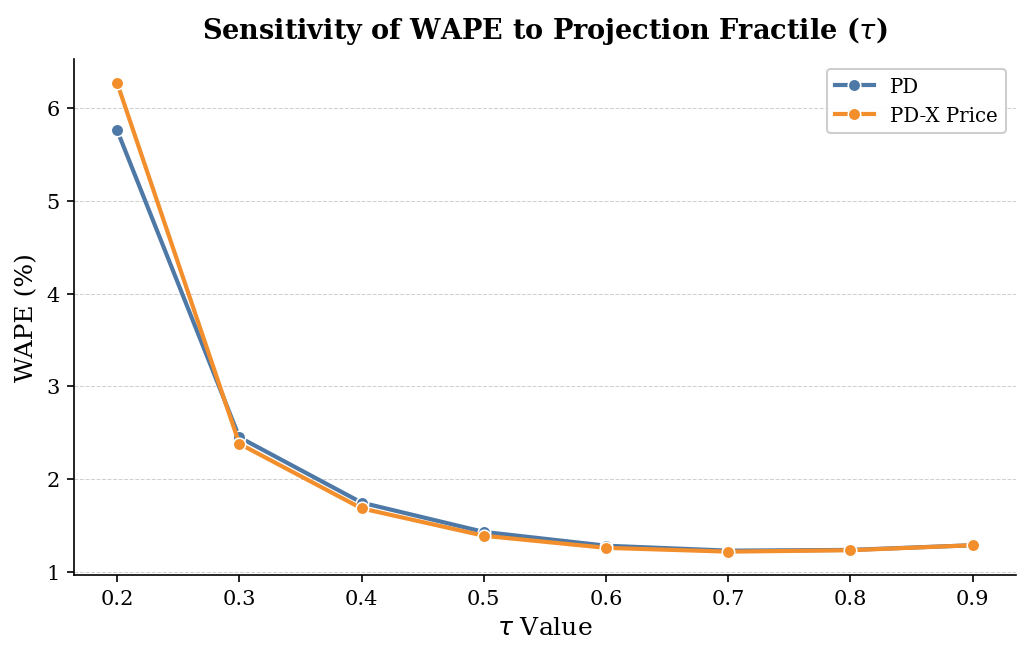

In [4]:
# Extract PD models and parse tau
pd_metrics = summary_df[(summary_df["Segment"] == "Total") & (summary_df["Model"].str.startswith("PD"))].copy()

def extract_tau(model_name):
    match = re.search(r'(\d+)$', model_name)
    if match: return float(match.group(1)) / 10.0
    return None

pd_metrics["Tau"] = pd_metrics["Model"].apply(extract_tau)
pd_metrics["Base_Model"] = pd_metrics["Model"].apply(lambda x: "PD-X Price" if "XPrice" in x else "PD")
pd_metrics = pd_metrics.sort_values("Tau")

# Plot
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#d0d0d0", zorder=0)
ax.set_axisbelow(True)

sns.lineplot(data=pd_metrics, x="Tau", y="WAPE", hue="Base_Model", marker="o", linewidth=2, palette=["#4E79A7", "#F28E2B"], ax=ax, zorder=3)

ax.set_title("Sensitivity of WAPE to Projection Fractile ($\\tau$)", fontweight="bold", pad=10)
ax.set_xlabel("$\\tau$ Value")
ax.set_ylabel("WAPE (%)")
ax.legend(title="", frameon=True, framealpha=0.95, edgecolor="#cccccc")

plt.tight_layout()
plt.show()

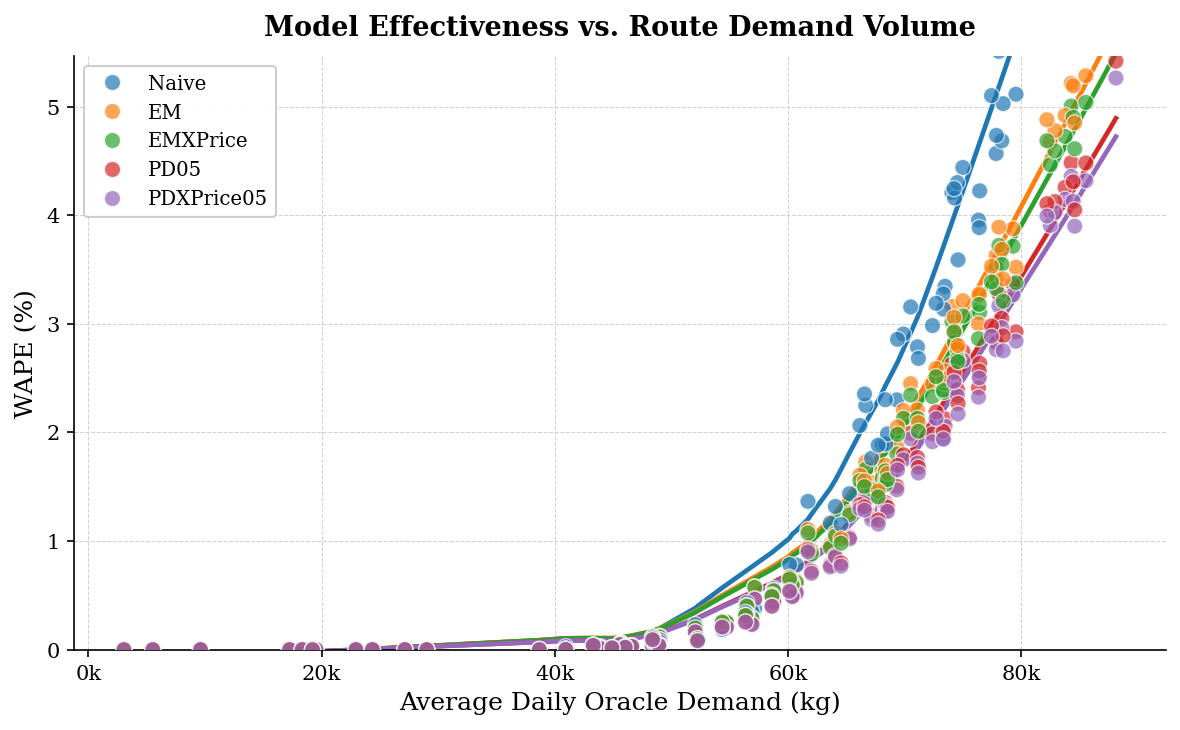

In [5]:
# Select models to compare
target_models = ["Naive", "EM", "EMXPrice", "PD05", "PDXPrice05"]
scatter_data = df_route_metrics[(df_route_metrics["Segment"] == "Total") & (df_route_metrics["Model"].isin(target_models))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#d0d0d0", zorder=0)
ax.xaxis.grid(True, linestyle="--", linewidth=0.5, color="#d0d0d0", zorder=0)
ax.set_axisbelow(True)

sns.scatterplot(
    data=scatter_data, x="Avg_Oracle_Demand", y="WAPE", 
    hue="Model", alpha=0.7, edgecolor="w", s=60, ax=ax, zorder=3
)

# Add LOESS trendlines
for model in target_models:
    mdl_data = scatter_data[scatter_data["Model"] == model]
    sns.regplot(
        data=mdl_data, x="Avg_Oracle_Demand", y="WAPE", 
        scatter=False, lowess=True, ax=ax, label="_nolegend_"
    )

ax.set_title("Model Effectiveness vs. Route Demand Volume", fontweight="bold", pad=10)
ax.set_xlabel("Average Daily Oracle Demand (kg)")
ax.set_ylabel("WAPE (%)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc")
ax.set_ylim(0, scatter_data["WAPE"].quantile(0.95) * 1.1) # Clip extreme outliers for visual clarity

plt.tight_layout()
plt.show()

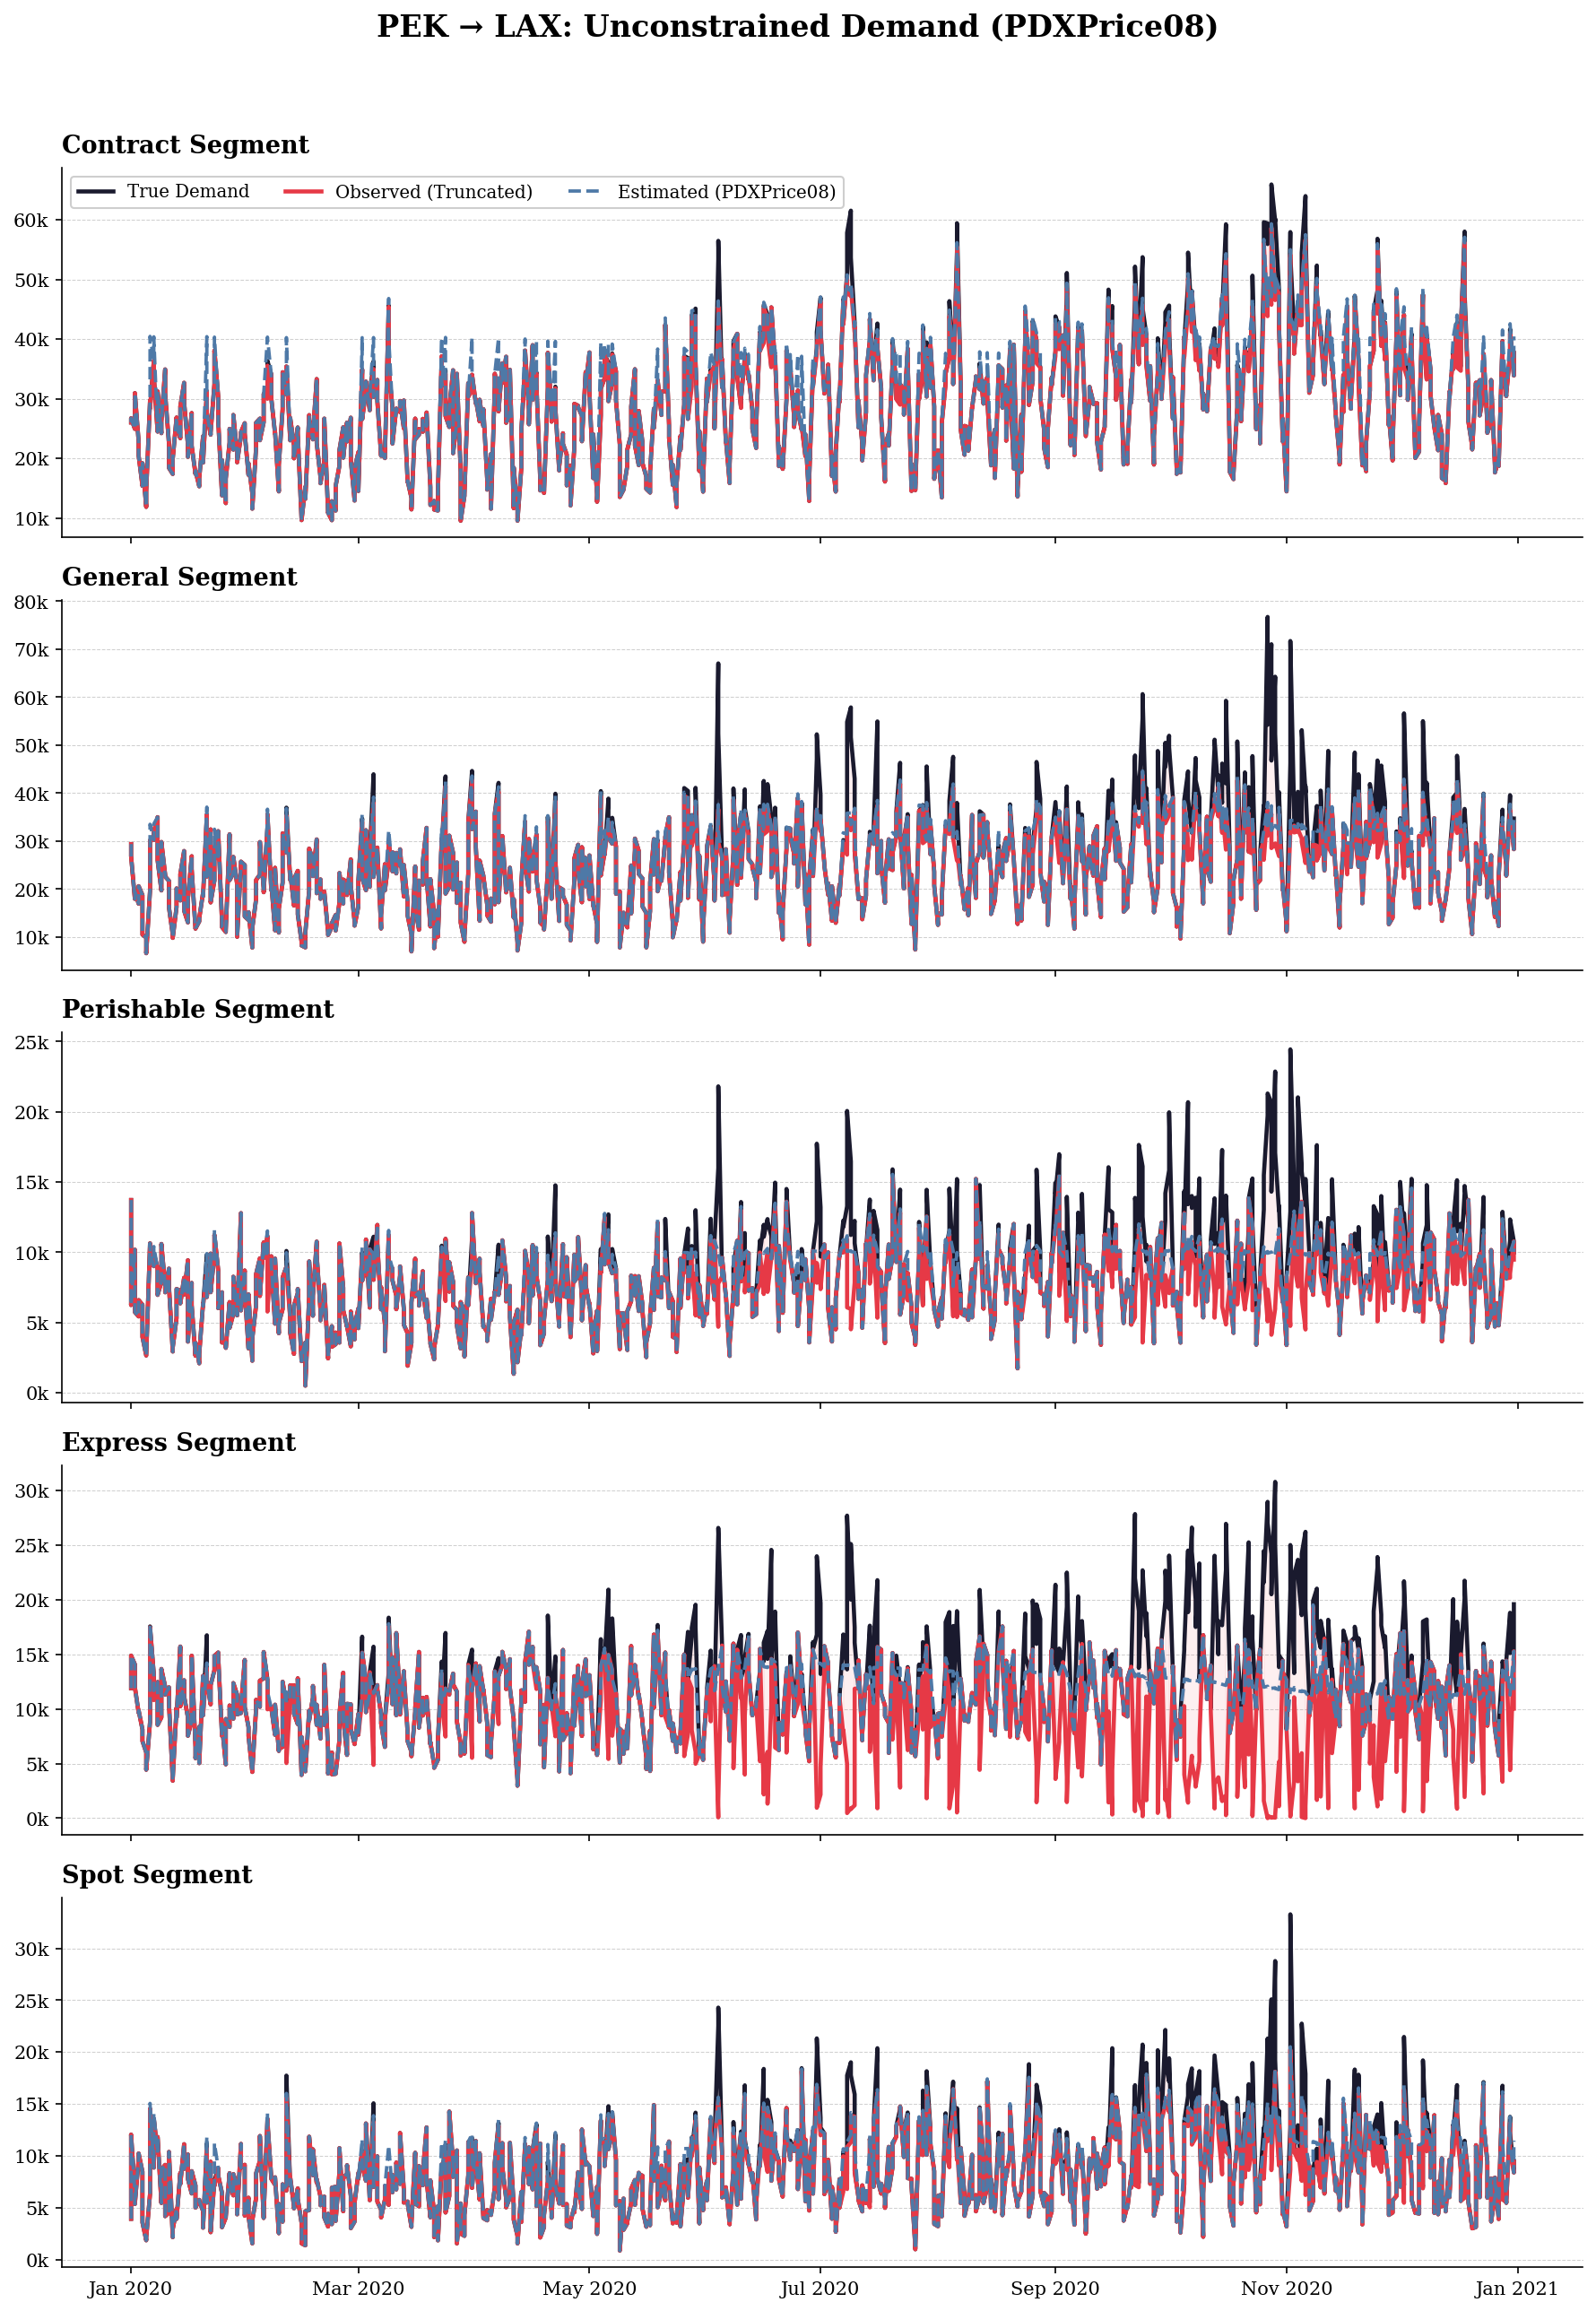

In [7]:
# Select specific slice and model
MODEL_TO_PLOT = "PDXPrice08"
viz_slice = df_analysis[(df_analysis["Origin"] == "PEK") & (df_analysis["Destination"] == "LAX")].copy()
viz_slice["Date"] = pd.to_datetime(viz_slice["Date"])
viz_slice = viz_slice[(viz_slice["Date"] >= "2020-01-01") & (viz_slice["Date"] <= "2021-12-31")].sort_values("Date")

fig, axes = plt.subplots(len(SEGMENTS), 1, figsize=(12, 3.5 * len(SEGMENTS)), sharex=True)
if len(SEGMENTS) == 1: axes = [axes]

for i, seg in enumerate(SEGMENTS):
    ax = axes[i]
    
    y_true = viz_slice[f"Oracle_{seg}_kg"].values
    y_obs  = viz_slice[f"Observed_{seg}_kg"].values
    y_pred = viz_slice[f"{MODEL_TO_PLOT}_{seg}_Est"].values
    dates  = viz_slice["Date"].values

    # Grid & Spines
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#d0d0d0", zorder=0)
    ax.set_axisbelow(True)

    # Plots
    ax.plot(dates, y_true, color=COLORS["Oracle"], linewidth=2.2, label="True Demand", zorder=4)
    ax.plot(dates, y_obs, color=COLORS["Observed"], linewidth=2.2, linestyle="-", label="Observed (Truncated)", zorder=5)
    ax.plot(dates, y_pred, color=COLORS["Estimate"], linewidth=1.8, linestyle="--", label=f"Estimated ({MODEL_TO_PLOT})", zorder=6)

    # Truncation Shading
    trunc_mask = y_true > y_obs
    ax.fill_between(dates, y_obs, y_true, where=trunc_mask, color=COLORS["Observed"], alpha=0.08, zorder=1)

    # Formatting
    ax.set_title(f"{seg} Segment", fontweight='bold', loc="left", pad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    
    if i == 0:
        ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", loc="upper left", ncol=3)

    if i == len(SEGMENTS) - 1:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=0)

fig.suptitle(f"PEK → LAX: Unconstrained Demand ({MODEL_TO_PLOT})", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()